# KMeans for Iris_datasets

In [33]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore",category=UserWarning)

<Axes: >

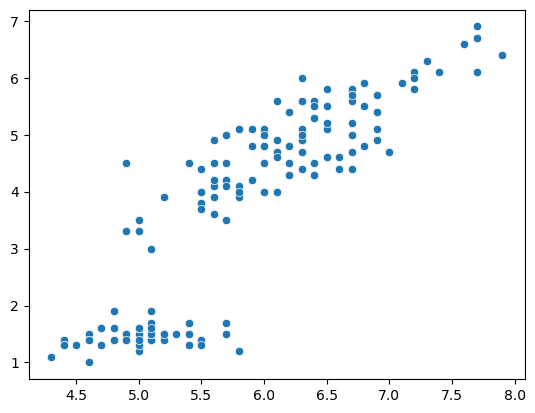

In [22]:
dt=load_iris()
X=dt.data
y=dt.target
sns.scatterplot(x=X[:,0],y=X[:,2])

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [38]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(X_scaled)

<Axes: >

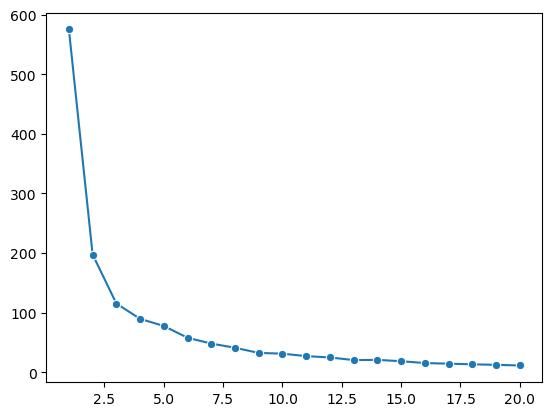

In [39]:
# find best K
wcss=[]

for k in range(1,21):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)
sns.lineplot(x=range(1,21),y=wcss,marker="o")

<Axes: >

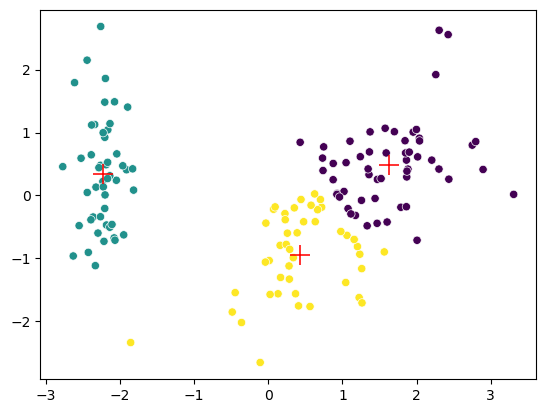

In [46]:
kmeans=KMeans(n_clusters=3,random_state=10)
labels=kmeans.fit_predict(pca_data)
sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],c="red",marker="+",s=200)